# ETF 动量 + R² 策略参数扫描回测

**策略逻辑：**
- 每隔 `rebal_period` 个交易日做一次调仓
- 调仓时，对每只 ETF 取过去 `n` 天的 log(收盘价)，做线性回归 log(P) = a + b·t
- 用 **斜率 b** 衡量动量强度，用 **R²** 衡量趋势质量
- 仅保留 R² ≥ 阈值的标的，从中选斜率最大的 top_k 只等权持有
- 若无标的通过筛选，该期空仓（收益为 0）

**扫描维度：** n (回看天数) × R² 阈值 × 调仓周期

In [51]:
import numpy as np
import pandas as pd
from pathlib import Path
from itertools import product
import warnings
warnings.filterwarnings('ignore')

DB_DIR = Path('db')

## 1. 加载数据

In [52]:
closes = {}
opens = {}
for fp in sorted(DB_DIR.glob('*.csv')):
    df = pd.read_csv(fp, index_col=0, parse_dates=True)
    if not df.empty and 'Close' in df.columns and len(df) >= 30:
        closes[fp.stem] = df['Close']
        if 'Open' in df.columns:
            opens[fp.stem] = df['Open']

# ffill 填充交易日间隙（ETF 上市前仍为 NaN，不会被错误填充）
panel = pd.DataFrame(closes).sort_index().ffill()
panel_open = pd.DataFrame(opens).sort_index().ffill()
print(f'加载 {panel.shape[1]} 只 ETF，{panel.shape[0]} 个交易日')
print(f'日期范围: {panel.index[0].strftime("%Y-%m-%d")} ~ {panel.index[-1].strftime("%Y-%m-%d")}')

加载 175 只 ETF，2917 个交易日
日期范围: 2014-03-05 ~ 2026-03-06


## 2. 回测引擎

利用滚动窗口向量化计算线性回归的斜率和 R²，避免逐只逐日循环。

In [53]:
def rolling_linreg(log_close: pd.DataFrame, n: int):
    """对 log(close) 面板做滚动 n 日线性回归，返回 slope 和 R² 面板。

    x = 0, 1, ..., n-1（固定），y = log(close) 滚动窗口。
    利用解析公式一次性算出全部日期 × 全部 ETF 的 slope / R²。
    """
    sum_x = n * (n - 1) / 2
    sum_x2 = n * (n - 1) * (2 * n - 1) / 6
    denom_x = n * sum_x2 - sum_x ** 2

    weights = np.arange(n, dtype=float)

    roll_sum_y = log_close.rolling(n).sum()
    roll_sum_y2 = (log_close ** 2).rolling(n).sum()
    roll_sum_xy = log_close.rolling(n).apply(lambda w: np.dot(weights, w), raw=True)

    slope = (n * roll_sum_xy - sum_x * roll_sum_y) / denom_x

    ss_tot = n * roll_sum_y2 - roll_sum_y ** 2
    ss_reg = (n * roll_sum_xy - sum_x * roll_sum_y) ** 2 / denom_x
    r2 = ss_reg / ss_tot.replace(0, np.nan)
    r2 = r2.clip(0, 1)

    return slope, r2


# 交易成本参数
SLIPPAGE = 0.001       # 滑点：以 open + 0.1% 买入
COMMISSION = 0.00006   # 单边手续费 0.006%

# 预计算中间量（后续回测复用）
log_close = np.log(panel.replace(0, np.nan))
daily_ret = panel.pct_change()
linreg_cache = {}

def precompute_linreg(n_list):
    """对所有 n 值预计算 slope / R²，缓存到 linreg_cache。"""
    for n in n_list:
        if n not in linreg_cache:
            linreg_cache[n] = rolling_linreg(log_close, n)
            print(f'  预计算 rolling_linreg(n={n}) 完成')


def backtest_momentum(
    slope: pd.DataFrame,
    r2: pd.DataFrame,
    daily_ret: pd.DataFrame,
    n: int,
    r2_threshold: float,
    rebal_period: int,
    top_k: int = 1,
    slippage: float = SLIPPAGE,
    commission: float = COMMISSION,
) -> pd.Series:
    """基于预计算的 slope/R² 运行回测，返回每日净值序列。

    实盘时序模型:
    - 信号日 T: 收盘后用 close 计算信号，决定下期持仓
    - 执行日 T+1: 卖旧 open*(1-slip)，买新 open*(1+slip)，扣手续费
    - 持仓期: 按 close-to-close 收益率
    """
    start_idx = n + 5
    dates = daily_ret.index[start_idx:]

    # 1) 每个调仓信号日计算选股结果
    rebal_indices = list(range(0, len(dates), rebal_period))
    signal_map = {}
    for idx_pos in rebal_indices:
        date = dates[idx_pos]
        s = slope.loc[date].dropna()
        r = r2.loc[date].dropna()
        common = s.index.intersection(r.index)
        s, r = s[common], r[common]
        candidates = s[r >= r2_threshold].sort_values(ascending=False)
        selected = candidates.head(top_k).index.tolist() if len(candidates) >= 1 else []
        signal_map[idx_pos] = selected

    # 2) 执行日 = 信号日 + 1
    exec_map = {}
    for sig_idx, selected in signal_map.items():
        exec_idx = sig_idx + 1
        if exec_idx < len(dates):
            exec_map[exec_idx] = selected

    # 3) 逐日模拟
    cum = 1.0
    nav_values = np.ones(len(dates))
    current_holdings = []

    for d in range(len(dates)):
        date = dates[d]

        if d in exec_map:
            new_holdings = exec_map[d]

            if sorted(new_holdings) != sorted(current_holdings):
                # 卖旧持仓: open*(1-slip)
                if current_holdings and d > 0:
                    prev_date = dates[d - 1]
                    sell_rets = []
                    for sym in current_holdings:
                        prev_cl = panel.loc[prev_date, sym]
                        op = panel_open.loc[date, sym] if (date in panel_open.index and sym in panel_open.columns) else panel.loc[date, sym]
                        sell_rets.append(op * (1 - slippage) / prev_cl - 1)
                    cum *= (1 + np.nanmean(sell_rets))
                    cum *= (1 - commission)

                # 买新持仓: open*(1+slip)，持有到当天收盘
                if new_holdings:
                    cum *= (1 - commission)
                    buy_rets = []
                    for sym in new_holdings:
                        op = panel_open.loc[date, sym] if (date in panel_open.index and sym in panel_open.columns) else panel.loc[date, sym]
                        cl = panel.loc[date, sym]
                        buy_rets.append(cl / (op * (1 + slippage)) - 1)
                    cum *= (1 + np.nanmean(buy_rets))

                current_holdings = new_holdings
            else:
                # 持仓未变，按正常 close-to-close
                if current_holdings:
                    ret = daily_ret.loc[date, current_holdings].mean()
                    if np.isnan(ret):
                        ret = 0.0
                    cum *= (1 + ret)
        else:
            # 普通持仓日
            if current_holdings:
                ret = daily_ret.loc[date, current_holdings].mean()
                if np.isnan(ret):
                    ret = 0.0
                cum *= (1 + ret)

        nav_values[d] = cum

    return pd.Series(nav_values, index=dates, name='NAV')

## 3. 定义参数网格

In [54]:
N_LIST = [5, 10, 15, 20, 22, 25, 30, 40]      # 动量回看天数
R2_LIST = [0.5, 0.6, 0.7, 0.8, 0.9]          # R² 阈值
REBAL_LIST = [1, 2, 3, 5, 10, 15, 20]                  # 调仓周期（交易日）
TOP_K_LIST = [1, 2, 3, 5, 10]                        # 每次持有 ETF 数量（网格）

param_grid = list(product(N_LIST, R2_LIST, REBAL_LIST, TOP_K_LIST))
print(f'参数组合数: {len(param_grid)}')

参数组合数: 1400


## 4. 批量回测

In [55]:
import time as _time

# 预计算所有 n 值的 slope / R²（最耗时的步骤，每个 n 只算一次）
print('预计算 rolling linreg ...')
precompute_linreg(N_LIST)

results = []
nav_cache = {}
t0 = _time.time()

for i, (n, r2_thresh, rebal, top_k) in enumerate(param_grid):
    label = f'n={n}_R2={r2_thresh}_rebal={rebal}_topk={top_k}'
    if (i + 1) % 20 == 0 or i == 0:
        print(f'  进度: {i+1}/{len(param_grid)} — {label}')

    slope, r2 = linreg_cache[n]
    nav = backtest_momentum(slope, r2, daily_ret, n=n, r2_threshold=r2_thresh,
                            rebal_period=rebal, top_k=top_k)
    nav_cache[label] = nav

    # 按自然年切分，计算每年收益率
    years = sorted(nav.index.year.unique())
    annual_rets = {}
    for yr in years:
        yr_nav = nav[nav.index.year == yr]
        if len(yr_nav) < 10:
            continue
        annual_rets[yr] = yr_nav.iloc[-1] / yr_nav.iloc[0] - 1

    full_years = [y for y in annual_rets if y != years[0] and y != years[-1]]
    avg_ret = np.mean([annual_rets[y] for y in full_years]) if full_years else np.nan

    row = {'n': n, 'R2_threshold': r2_thresh, 'rebal_period': rebal, 'top_k': top_k}
    row.update(annual_rets)
    row['avg_full_year'] = avg_ret
    total_ret = nav.iloc[-1] / nav.iloc[0] - 1
    n_years = (nav.index[-1] - nav.index[0]).days / 365.25
    row['annualized'] = (1 + total_ret) ** (1 / n_years) - 1 if n_years > 0 else np.nan
    row['total_ret'] = total_ret
    row['max_drawdown'] = ((nav / nav.cummax()) - 1).min()
    results.append(row)

elapsed = _time.time() - t0
print(f'\n回测完成，共 {len(results)} 组参数，耗时 {elapsed:.1f}s')

预计算 rolling linreg ...
  预计算 rolling_linreg(n=5) 完成
  预计算 rolling_linreg(n=10) 完成
  预计算 rolling_linreg(n=15) 完成
  预计算 rolling_linreg(n=20) 完成
  预计算 rolling_linreg(n=22) 完成
  预计算 rolling_linreg(n=25) 完成
  预计算 rolling_linreg(n=30) 完成
  预计算 rolling_linreg(n=40) 完成
  进度: 1/1400 — n=5_R2=0.5_rebal=1_topk=1
  进度: 20/1400 — n=5_R2=0.5_rebal=5_topk=10
  进度: 40/1400 — n=5_R2=0.6_rebal=1_topk=10
  进度: 60/1400 — n=5_R2=0.6_rebal=10_topk=10
  进度: 80/1400 — n=5_R2=0.7_rebal=2_topk=10
  进度: 100/1400 — n=5_R2=0.7_rebal=15_topk=10
  进度: 120/1400 — n=5_R2=0.8_rebal=3_topk=10
  进度: 140/1400 — n=5_R2=0.8_rebal=20_topk=10
  进度: 160/1400 — n=5_R2=0.9_rebal=5_topk=10
  进度: 180/1400 — n=10_R2=0.5_rebal=1_topk=10
  进度: 200/1400 — n=10_R2=0.5_rebal=10_topk=10
  进度: 220/1400 — n=10_R2=0.6_rebal=2_topk=10
  进度: 240/1400 — n=10_R2=0.6_rebal=15_topk=10
  进度: 260/1400 — n=10_R2=0.7_rebal=3_topk=10
  进度: 280/1400 — n=10_R2=0.7_rebal=20_topk=10
  进度: 300/1400 — n=10_R2=0.8_rebal=5_topk=10
  进度: 320/1400 — n=10_R2=0.9

## 5. 结果总览

In [56]:
result_df = pd.DataFrame(results)
result_df.to_csv('backtest_result.csv', index=False, encoding='utf-8-sig')

year_cols = [c for c in result_df.columns if isinstance(c, (int, np.integer))]
fmt_cols = year_cols + ['avg_full_year', 'annualized', 'total_ret', 'max_drawdown']

display_df = result_df.copy()
for c in fmt_cols:
    if c in display_df.columns:
        display_df[c] = display_df[c].map(lambda x: f'{x:.2%}' if pd.notna(x) else '-')

display_df = display_df.sort_values('annualized', ascending=False, key=lambda s: result_df['annualized'])

print('所有参数组合回测结果（按年化收益排序）:')
display(display_df.head(30))

所有参数组合回测结果（按年化收益排序）:


,n,R2_threshold,rebal_period,top_k,2014,2015,2016,2017,2018,2019,...,2021,2022,2023,2024,2025,2026,avg_full_year,annualized,total_ret,max_drawdown
382,15,0.5,20,3,47.71%,-2.98%,19.55%,58.65%,-19.75%,37.29%,...,377.08%,-3.33%,3.68%,-1.08%,5.41%,30.27%,44.31%,29.56%,2095.06%,-53.30%
1256,40,0.5,20,2,43.96%,38.55%,-1.46%,27.66%,-10.33%,-0.07%,...,273.34%,-14.65%,13.56%,12.66%,53.20%,-2.50%,38.14%,27.29%,1630.83%,-53.96%
384,15,0.5,20,10,24.90%,12.94%,67.74%,59.48%,-22.89%,34.64%,...,139.08%,9.83%,-4.76%,-3.93%,16.76%,14.34%,29.79%,25.41%,1388.38%,-41.46%
1241,40,0.5,5,2,64.46%,37.46%,0.12%,-1.20%,-17.25%,-8.12%,...,337.79%,3.43%,2.62%,-3.05%,29.87%,15.43%,36.22%,24.89%,1282.87%,-58.07%
383,15,0.5,20,5,29.55%,4.27%,12.64%,48.64%,-20.32%,42.44%,...,241.54%,10.28%,-4.71%,-0.61%,8.00%,21.07%,32.44%,24.39%,1250.90%,-52.10%
418,15,0.6,20,5,12.14%,6.17%,15.21%,52.02%,-19.37%,40.96%,...,243.48%,11.41%,-7.71%,-11.82%,20.18%,21.07%,33.41%,23.61%,1152.87%,-43.52%
1246,40,0.5,10,2,70.45%,35.74%,-5.21%,2.81%,-19.29%,-13.22%,...,255.16%,-6.11%,19.16%,8.63%,22.00%,14.59%,28.88%,22.77%,1029.54%,-56.77%
419,15,0.6,20,10,12.59%,7.63%,30.85%,70.59%,-20.74%,41.08%,...,134.30%,10.30%,-9.97%,-8.43%,26.84%,14.28%,27.09%,22.09%,980.49%,-44.35%
417,15,0.6,20,3,17.51%,-6.33%,-24.17%,61.09%,-15.12%,45.12%,...,373.32%,-5.35%,-3.47%,-7.31%,8.96%,30.27%,40.13%,21.87%,958.19%,-61.84%
453,15,0.7,20,5,3.35%,25.26%,28.28%,16.94%,-22.11%,42.25%,...,189.88%,8.33%,-7.53%,-6.53%,30.73%,10.08%,29.43%,21.67%,936.88%,-44.92%


## 6. 最优参数组合 Top 10

In [59]:
top10 = result_df.nlargest(10, 'annualized')[['n', 'R2_threshold', 'rebal_period', 'top_k'] + year_cols + ['avg_full_year', 'annualized', 'total_ret', 'max_drawdown']].copy()
for c in fmt_cols:
    if c in top10.columns:
        top10[c] = top10[c].map(lambda x: f'{x:.2%}' if pd.notna(x) else '-')
top10.index = range(1, len(top10) + 1)
top10.index.name = '排名'
print('年化收益 Top 10 参数组合:')
display(top10)

年化收益 Top 10 参数组合:


,n,R2_threshold,rebal_period,top_k,2014,2015,2016,2017,2018,2019,...,2021,2022,2023,2024,2025,2026,avg_full_year,annualized,total_ret,max_drawdown
排名,,,,,,,,,,,,,,,,,,,,,
1,15,0.5,20,3,47.71%,-2.98%,19.55%,58.65%,-19.75%,37.29%,...,377.08%,-3.33%,3.68%,-1.08%,5.41%,30.27%,44.31%,29.56%,2095.06%,-53.30%
2,40,0.5,20,2,43.96%,38.55%,-1.46%,27.66%,-10.33%,-0.07%,...,273.34%,-14.65%,13.56%,12.66%,53.20%,-2.50%,38.14%,27.29%,1630.83%,-53.96%
3,15,0.5,20,10,24.90%,12.94%,67.74%,59.48%,-22.89%,34.64%,...,139.08%,9.83%,-4.76%,-3.93%,16.76%,14.34%,29.79%,25.41%,1388.38%,-41.46%
4,40,0.5,5,2,64.46%,37.46%,0.12%,-1.20%,-17.25%,-8.12%,...,337.79%,3.43%,2.62%,-3.05%,29.87%,15.43%,36.22%,24.89%,1282.87%,-58.07%
5,15,0.5,20,5,29.55%,4.27%,12.64%,48.64%,-20.32%,42.44%,...,241.54%,10.28%,-4.71%,-0.61%,8.00%,21.07%,32.44%,24.39%,1250.90%,-52.10%
6,15,0.6,20,5,12.14%,6.17%,15.21%,52.02%,-19.37%,40.96%,...,243.48%,11.41%,-7.71%,-11.82%,20.18%,21.07%,33.41%,23.61%,1152.87%,-43.52%
7,40,0.5,10,2,70.45%,35.74%,-5.21%,2.81%,-19.29%,-13.22%,...,255.16%,-6.11%,19.16%,8.63%,22.00%,14.59%,28.88%,22.77%,1029.54%,-56.77%
8,15,0.6,20,10,12.59%,7.63%,30.85%,70.59%,-20.74%,41.08%,...,134.30%,10.30%,-9.97%,-8.43%,26.84%,14.28%,27.09%,22.09%,980.49%,-44.35%
9,15,0.6,20,3,17.51%,-6.33%,-24.17%,61.09%,-15.12%,45.12%,...,373.32%,-5.35%,-3.47%,-7.31%,8.96%,30.27%,40.13%,21.87%,958.19%,-61.84%


## 7. 热力图分析

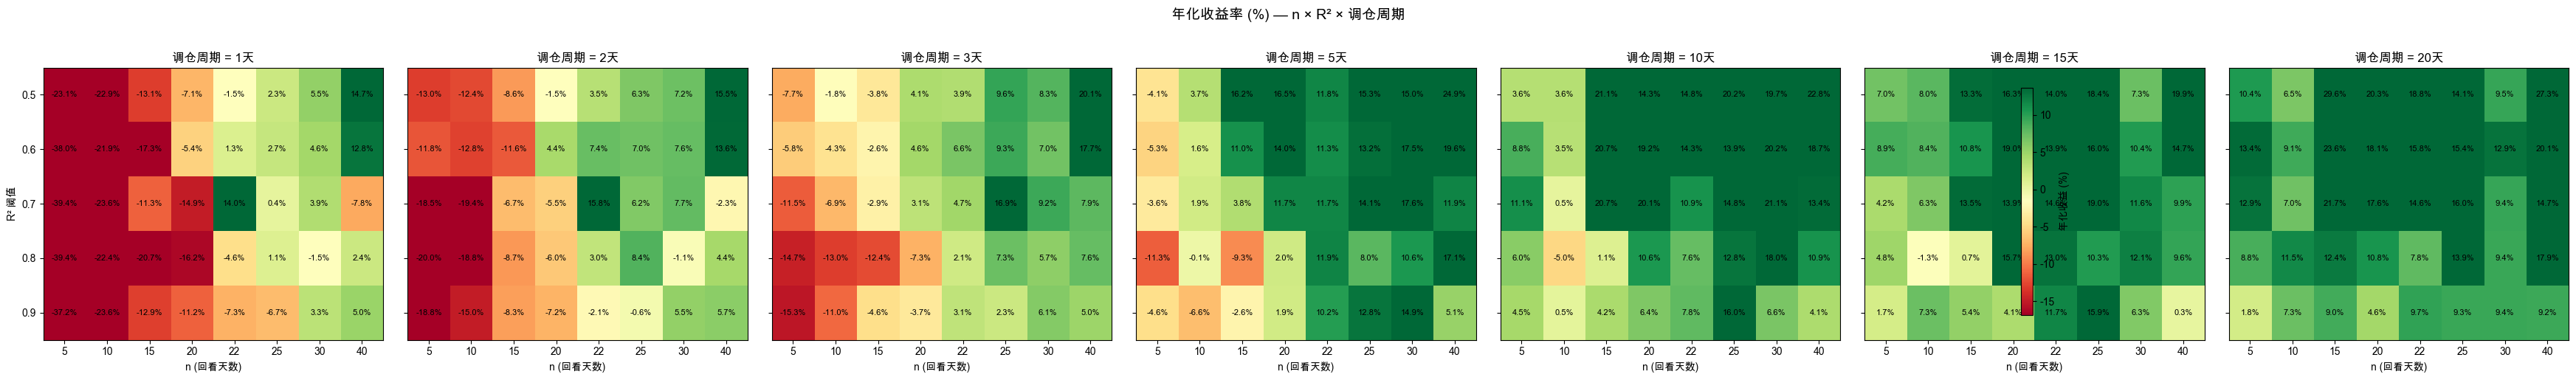

In [60]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'Heiti TC']
matplotlib.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, len(REBAL_LIST), figsize=(5 * len(REBAL_LIST), 5), sharey=True)
if len(REBAL_LIST) == 1:
    axes = [axes]

for ax, rebal in zip(axes, REBAL_LIST):
    subset = result_df[result_df['rebal_period'] == rebal]
    # 每个 (R2_threshold, n) 有多个 top_k，取年化最大后再 pivot
    agg = subset.groupby(['R2_threshold', 'n'], as_index=False)['annualized'].max()
    pivot = agg.pivot(index='R2_threshold', columns='n', values='annualized') * 100
    im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto',
                   vmin=result_df['annualized'].quantile(0.1) * 100,
                   vmax=result_df['annualized'].quantile(0.9) * 100)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'{v:.1f}' for v in pivot.index])
    ax.set_xlabel('n (回看天数)')
    if rebal == REBAL_LIST[0]:
        ax.set_ylabel('R² 阈值')
    ax.set_title(f'调仓周期 = {rebal}天')

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.1f}%', ha='center', va='center', fontsize=8)

fig.suptitle('年化收益率 (%) — n × R² × 调仓周期', fontsize=14, y=1.02)
fig.colorbar(im, ax=axes, label='年化收益 (%)', shrink=0.8)
plt.tight_layout()
plt.show()

## 8. 最优 & 基准净值曲线

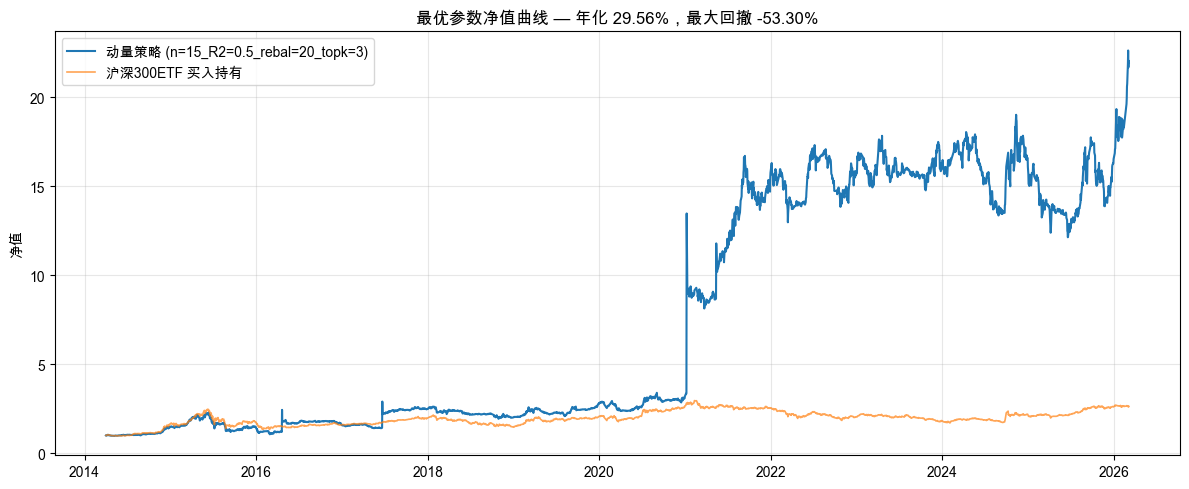

最优参数: n=15, R²≥0.5, 调仓周期=20天, top_k=3
年化收益: 29.56%
累计收益: 2095.06%
最大回撤: -53.30%


In [61]:
best_row = result_df.nlargest(1, 'annualized').iloc[0]
best_label = f"n={int(best_row['n'])}_R2={best_row['R2_threshold']}_rebal={int(best_row['rebal_period'])}_topk={int(best_row['top_k'])}"
best_nav = nav_cache[best_label]

# 基准：沪深300 ETF (SH510300) 买入持有
bench_sym = 'SH510300'
if bench_sym in panel.columns:
    bench = panel[bench_sym].reindex(best_nav.index).ffill()
    bench_nav = bench / bench.iloc[0]
else:
    bench_nav = None

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(best_nav.index, best_nav.values, label=f'动量策略 ({best_label})', linewidth=1.5)
if bench_nav is not None:
    ax.plot(bench_nav.index, bench_nav.values, label='沪深300ETF 买入持有', linewidth=1.2, alpha=0.7)
ax.set_ylabel('净值')
ax.set_title(f'最优参数净值曲线 — 年化 {best_row["annualized"]:.2%}，最大回撤 {best_row["max_drawdown"]:.2%}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'最优参数: n={int(best_row["n"])}, R²≥{best_row["R2_threshold"]}, 调仓周期={int(best_row["rebal_period"])}天, top_k={int(best_row["top_k"])}')
print(f'年化收益: {best_row["annualized"]:.2%}')
print(f'累计收益: {best_row["total_ret"]:.2%}')
print(f'最大回撤: {best_row["max_drawdown"]:.2%}')

## 9. 按维度聚合分析

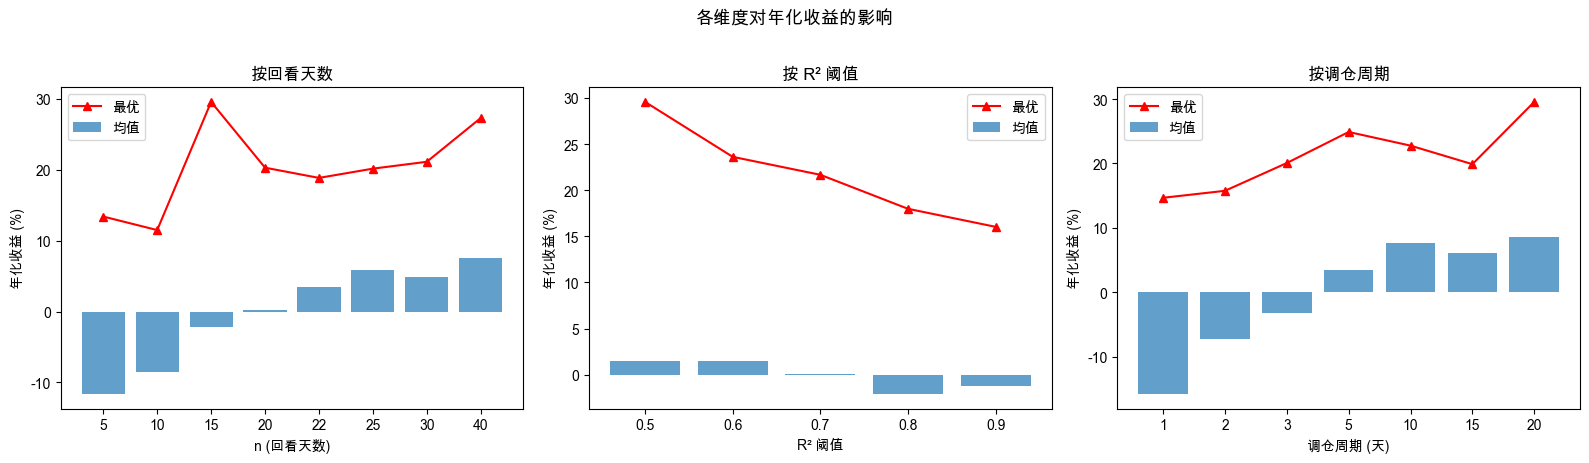

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 按 n 聚合
by_n = result_df.groupby('n')['annualized'].agg(['mean', 'max'])
axes[0].bar(by_n.index.astype(str), by_n['mean'] * 100, alpha=0.7, label='均值')
axes[0].plot(by_n.index.astype(str), by_n['max'] * 100, 'r^-', label='最优')
axes[0].set_xlabel('n (回看天数)')
axes[0].set_ylabel('年化收益 (%)')
axes[0].set_title('按回看天数')
axes[0].legend()

# 按 R² 聚合
by_r2 = result_df.groupby('R2_threshold')['annualized'].agg(['mean', 'max'])
axes[1].bar(by_r2.index.astype(str), by_r2['mean'] * 100, alpha=0.7, label='均值')
axes[1].plot(by_r2.index.astype(str), by_r2['max'] * 100, 'r^-', label='最优')
axes[1].set_xlabel('R² 阈值')
axes[1].set_ylabel('年化收益 (%)')
axes[1].set_title('按 R² 阈值')
axes[1].legend()

# 按调仓周期聚合
by_rebal = result_df.groupby('rebal_period')['annualized'].agg(['mean', 'max'])
axes[2].bar(by_rebal.index.astype(str), by_rebal['mean'] * 100, alpha=0.7, label='均值')
axes[2].plot(by_rebal.index.astype(str), by_rebal['max'] * 100, 'r^-', label='最优')
axes[2].set_xlabel('调仓周期 (天)')
axes[2].set_ylabel('年化收益 (%)')
axes[2].set_title('按调仓周期')
axes[2].legend()

fig.suptitle('各维度对年化收益的影响', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 10. 每年收益率详细对比

In [63]:
# 选出 Top5 参数，展示逐年收益率对比
top5 = result_df.nlargest(5, 'annualized')

year_data = []
for _, row in top5.iterrows():
    label = f"n={int(row['n'])},R²≥{row['R2_threshold']},T={int(row['rebal_period'])},top_k={int(row['top_k'])}"
    entry = {'参数': label}
    for yr in year_cols:
        entry[str(yr)] = row[yr]
    entry['完整年均值'] = row['avg_full_year']
    entry['年化'] = row['annualized']
    entry['最大回撤'] = row['max_drawdown']
    year_data.append(entry)

year_df = pd.DataFrame(year_data).set_index('参数')

styled = year_df.style.format('{:.2%}').background_gradient(
    cmap='RdYlGn', axis=None, subset=[c for c in year_df.columns if c != '最大回撤']
).background_gradient(
    cmap='RdYlGn_r', axis=None, subset=['最大回撤']
)
display(styled)

,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026,完整年均值,年化,最大回撤
参数,,,,,,,,,,,,,,,,
"n=15,R²≥0.5,T=20,top_k=3",47.71%,-2.98%,19.55%,58.65%,-19.75%,37.29%,12.95%,377.08%,-3.33%,3.68%,-1.08%,5.41%,30.27%,44.31%,29.56%,-53.30%
"n=40,R²≥0.5,T=20,top_k=2",43.96%,38.55%,-1.46%,27.66%,-10.33%,-0.07%,27.08%,273.34%,-14.65%,13.56%,12.66%,53.20%,-2.50%,38.14%,27.29%,-53.96%
"n=15,R²≥0.5,T=20,top_k=10",24.90%,12.94%,67.74%,59.48%,-22.89%,34.64%,18.81%,139.08%,9.83%,-4.76%,-3.93%,16.76%,14.34%,29.79%,25.41%,-41.46%
"n=40,R²≥0.5,T=5,top_k=2",64.46%,37.46%,0.12%,-1.20%,-17.25%,-8.12%,16.71%,337.79%,3.43%,2.62%,-3.05%,29.87%,15.43%,36.22%,24.89%,-58.07%
"n=15,R²≥0.5,T=20,top_k=5",29.55%,4.27%,12.64%,48.64%,-20.32%,42.44%,14.71%,241.54%,10.28%,-4.71%,-0.61%,8.00%,21.07%,32.44%,24.39%,-52.10%


## 11. 最优参数调仓明细（n=5, R²≥0.6, rebal=5, top_k=1）

In [64]:
import json as _json
with open('etf_all.json') as _f:
    _etf_data = _json.load(_f)
etf_name_map = {item['symbol']: item['name'] for item in _etf_data['data']['list']}

BEST_N, BEST_R2, BEST_REBAL, BEST_TOPK = 5, 0.6, 5, 1

slope, r2 = linreg_cache[BEST_N]
start_idx = BEST_N + 5
dates = daily_ret.index[start_idx:]
rebal_indices = list(range(0, len(dates), BEST_REBAL))

trades = []
cum = 1.0
prev_selected = []

for i, idx_pos in enumerate(rebal_indices):
    date = dates[idx_pos]
    s = slope.loc[date].dropna()
    r = r2.loc[date].dropna()
    common = s.index.intersection(r.index)
    s, r = s[common], r[common]

    candidates = s[r >= BEST_R2].sort_values(ascending=False)
    selected = candidates.head(BEST_TOPK).index.tolist() if len(candidates) >= 1 else []

    # T日信号 → T+1日执行
    exec_idx = idx_pos + 1
    if exec_idx >= len(dates):
        break

    # 下一个信号日 → 下一个执行日
    next_signal_idx = rebal_indices[i + 1] if i + 1 < len(rebal_indices) else len(dates) - 1
    next_exec_idx = next_signal_idx + 1

    signal_date = dates[idx_pos]
    exec_date = dates[exec_idx]

    # 手续费（持仓变化才收）
    changed = sorted(selected) != sorted(prev_selected)
    trade_cost = 0.0
    if changed:
        if prev_selected:
            trade_cost += COMMISSION
        if selected:
            trade_cost += COMMISSION
        cum *= (1 - trade_cost)

    if selected:
        # 每只标的：买入价 = exec日 open*(1+slip)
        buy_prices = {}
        for sym in selected:
            op = panel_open.loc[exec_date, sym] if (exec_date in panel_open.index and sym in panel_open.columns) else panel.loc[exec_date, sym]
            buy_prices[sym] = op * (1 + SLIPPAGE)

        # 卖出价 = 下个执行日 open*(1-slip)，最后一期取最后收盘价
        sell_prices = {}
        if next_exec_idx < len(dates):
            sell_date = dates[next_exec_idx]
            for sym in selected:
                op = panel_open.loc[sell_date, sym] if (sell_date in panel_open.index and sym in panel_open.columns) else panel.loc[sell_date, sym]
                sell_prices[sym] = op * (1 - SLIPPAGE)
        else:
            sell_date = dates[-1]
            for sym in selected:
                sell_prices[sym] = panel.loc[sell_date, sym]

        # 收益 = 各标的 (卖出价/买入价 - 1) 的均值
        per_stock_rets = [(sell_prices[sym] / buy_prices[sym] - 1) for sym in selected]
        period_ret = np.mean(per_stock_rets)
        cum *= (1 + period_ret)

        buy_str = ','.join(f'{buy_prices[s]:.4f}' for s in selected)
        sell_str = ','.join(f'{sell_prices[s]:.4f}' for s in selected)
    else:
        period_ret = 0.0
        sell_date = dates[min(next_signal_idx, len(dates) - 1)]
        buy_str = '-'
        sell_str = '-'

    prev_selected = selected

    trades.append({
        '标的': ','.join(selected) if selected else '空仓',
        '名称': ','.join(etf_name_map.get(s, '-') for s in selected) if selected else '-',
        '信号日(T)': signal_date.strftime('%Y-%m-%d'),
        '执行日(T+1)': exec_date.strftime('%Y-%m-%d'),
        '买入价(open×1.001)': buy_str,
        '卖出日': sell_date.strftime('%Y-%m-%d'),
        '卖出价(open×0.999)': sell_str,
        '收益(卖/买-1)': f'{period_ret:.2%}',
        '手续费': f'{trade_cost:.4%}',
        '总净值': round(cum, 4),
    })

trade_df = pd.DataFrame(trades)
trade_df.to_csv('trade_detail.csv', index=False, encoding='utf-8-sig')
print(f'共 {len(trade_df)} 次调仓，已导出 trade_detail.csv')
display(trade_df)

共 582 次调仓，已导出 trade_detail.csv


,标的,名称,信号日(T),执行日(T+1),买入价(open×1.001),卖出日,卖出价(open×0.999),收益(卖/买-1),手续费,总净值
0,SH510500,中证500ETF,2014-03-19,2014-03-20,3.3287,2014-03-27,3.3400,0.34%,0.0060%,1.0033
1,SH510900,恒生中国企业ETF易方达,2014-03-26,2014-03-27,0.8326,2014-04-03,0.8556,2.77%,0.0120%,1.0310
2,SZ159920,恒生ETF,2014-04-02,2014-04-03,0.9738,2014-04-11,0.9956,2.24%,0.0120%,1.0539
3,SH510230,金融ETF,2014-04-10,2014-04-11,0.4983,2014-04-18,0.4753,-4.61%,0.0120%,1.0052
4,SH513500,标普500ETF博时,2014-04-17,2014-04-18,0.5190,2014-04-25,0.5215,0.47%,0.0120%,1.0099
...,...,...,...,...,...,...,...,...,...,...
577,SH517520,黄金股ETF,2026-01-28,2026-01-29,3.3033,2026-02-05,2.5375,-23.18%,0.0120%,0.3526
578,SZ159326,电网设备ETF,2026-02-04,2026-02-05,1.7958,2026-02-12,1.8182,1.25%,0.0120%,0.3570
579,SH516620,影视ETF,2026-02-11,2026-02-12,1.2863,2026-02-27,1.1578,-9.99%,0.0120%,0.3213
580,SH513310,中韩半导体ETF,2026-02-26,2026-02-27,4.3253,2026-03-06,4.0969,-5.28%,0.0120%,0.3043


## 12. 当前应持仓标的（n=5, R²≥0.6, top_k=1）

In [48]:
latest_date = panel.index[-1]
s_now = slope.loc[latest_date].dropna()
r_now = r2.loc[latest_date].dropna()
common = s_now.index.intersection(r_now.index)
s_now, r_now = s_now[common], r_now[common]

candidates = s_now[r_now >= BEST_R2].sort_values(ascending=False)

print(f'策略参数: n={BEST_N}, R²≥{BEST_R2}, rebal={BEST_REBAL}, top_k={BEST_TOPK}')
print(f'信号日期: {latest_date.strftime("%Y-%m-%d")}')
print()

if len(candidates) >= 1:
    pick = candidates.head(BEST_TOPK)
    print('当前应持仓标的:')
    for sym, slp in pick.items():
        r2_val = r_now[sym]
        price = panel.loc[latest_date, sym]
        name = etf_name_map.get(sym, '')
        print(f'  {sym} {name}  斜率={slp:.6f}  R²={r2_val:.4f}  最新价={price:.4f}')
else:
    print('当前无标的通过筛选 → 空仓')

print()
print(f'所有通过 R²≥{BEST_R2} 筛选的候选标的 (共 {len(candidates)} 只):')
cand_df = pd.DataFrame({
    '标的': candidates.index,
    '名称': [etf_name_map.get(s, '') for s in candidates.index],
    '斜率': candidates.values,
    'R²': [r_now[s] for s in candidates.index],
    '最新价': [panel.loc[latest_date, s] for s in candidates.index],
}).reset_index(drop=True)
display(cand_df.head(20))

策略参数: n=5, R²≥0.6, rebal=5, top_k=1
信号日期: 2026-03-06

当前应持仓标的:
  SZ159985 豆粕ETF  斜率=0.009334  R²=0.6522  最新价=2.1260

所有通过 R²≥0.6 筛选的候选标的 (共 17 只):


,标的,名称,斜率,R²,最新价
0,SZ159985,豆粕ETF,0.009334,0.652172,2.126000
1,SZ159611,电力ETF,0.007158,0.688575,1.135000
2,SH511030,公司债ETF,0.000201,0.865243,107.232002
3,SH511260,十年国债ETF,0.000184,0.853639,135.287003
4,SZ159972,5年地债ETF,0.000160,0.779781,117.888000
5,SH511360,短融ETF海富通,0.000073,0.937529,113.134003
6,SZ159209,中证红利质量ETF,-0.005693,0.609278,1.268000
7,SZ159707,地产ETF,-0.007930,0.703661,0.610000
8,SH510170,大宗商品ETF,-0.012202,0.915726,1.566000
9,SH518880,黄金ETF,-0.012419,0.911671,10.873000


## 13. 近 3 年回测 Top 10 参数

In [50]:
import time as _time

panel_3y = panel.loc[panel.index >= panel.index[-1] - pd.DateOffset(years=3)]
log_close_3y = np.log(panel_3y.replace(0, np.nan))
daily_ret_3y = panel_3y.pct_change()

linreg_cache_3y = {}
for n in N_LIST:
    linreg_cache_3y[n] = rolling_linreg(log_close_3y, n)
print('近3年 rolling_linreg 预计算完成')

results_3y = []
t0 = _time.time()

for i, (n, r2_thresh, rebal, top_k) in enumerate(param_grid):
    label = f'n={n}_R2={r2_thresh}_rebal={rebal}_topk={top_k}'
    if (i + 1) % 100 == 0 or i == 0:
        print(f'  进度: {i+1}/{len(param_grid)} — {label}')

    slope_3y, r2_3y = linreg_cache_3y[n]
    nav = backtest_momentum(slope_3y, r2_3y, daily_ret_3y, n=n,
                            r2_threshold=r2_thresh, rebal_period=rebal, top_k=top_k)

    years = sorted(nav.index.year.unique())
    annual_rets = {}
    for yr in years:
        yr_nav = nav[nav.index.year == yr]
        if len(yr_nav) < 10:
            continue
        annual_rets[yr] = yr_nav.iloc[-1] / yr_nav.iloc[0] - 1

    full_years = [y for y in annual_rets if y != years[0] and y != years[-1]]
    avg_ret = np.mean([annual_rets[y] for y in full_years]) if full_years else np.nan

    row = {'n': n, 'R2_threshold': r2_thresh, 'rebal_period': rebal, 'top_k': top_k}
    row.update(annual_rets)
    row['avg_full_year'] = avg_ret
    total_ret = nav.iloc[-1] / nav.iloc[0] - 1
    n_years = (nav.index[-1] - nav.index[0]).days / 365.25
    row['annualized'] = (1 + total_ret) ** (1 / n_years) - 1 if n_years > 0 else np.nan
    row['total_ret'] = total_ret
    row['max_drawdown'] = ((nav / nav.cummax()) - 1).min()
    results_3y.append(row)

elapsed = _time.time() - t0
print(f'\n近3年回测完成，共 {len(results_3y)} 组参数，耗时 {elapsed:.1f}s')

result_3y_df = pd.DataFrame(results_3y)
year_cols_3y = [c for c in result_3y_df.columns if isinstance(c, (int, np.integer))]
fmt_cols_3y = year_cols_3y + ['avg_full_year', 'annualized', 'total_ret', 'max_drawdown']

top10_3y = result_3y_df.nlargest(10, 'annualized')[
    ['n', 'R2_threshold', 'rebal_period', 'top_k'] + year_cols_3y +
    ['avg_full_year', 'annualized', 'total_ret', 'max_drawdown']
].copy()

for c in fmt_cols_3y:
    if c in top10_3y.columns:
        top10_3y[c] = top10_3y[c].map(lambda x: f'{x:.2%}' if pd.notna(x) else '-')

result_3y_df.to_csv('backtest_result_3.csv', index=False, encoding='utf-8-sig')

print(f'\n近3年数据范围: {panel_3y.index[0].strftime("%Y-%m-%d")} ~ {panel_3y.index[-1].strftime("%Y-%m-%d")}')
print(f'已导出 backtest_result_3.csv（共 {len(result_3y_df)} 条）')
print('近3年回测 Top 10 参数组合:')
display(top10_3y)

近3年 rolling_linreg 预计算完成
  进度: 1/1400 — n=5_R2=0.5_rebal=1_topk=1
  进度: 100/1400 — n=5_R2=0.7_rebal=15_topk=10
  进度: 200/1400 — n=10_R2=0.5_rebal=10_topk=10
  进度: 300/1400 — n=10_R2=0.8_rebal=5_topk=10
  进度: 400/1400 — n=15_R2=0.6_rebal=3_topk=10
  进度: 500/1400 — n=15_R2=0.9_rebal=2_topk=10
  进度: 600/1400 — n=20_R2=0.7_rebal=1_topk=10
  进度: 700/1400 — n=20_R2=0.9_rebal=20_topk=10
  进度: 800/1400 — n=22_R2=0.7_rebal=15_topk=10
  进度: 900/1400 — n=25_R2=0.5_rebal=10_topk=10
  进度: 1000/1400 — n=25_R2=0.8_rebal=5_topk=10
  进度: 1100/1400 — n=30_R2=0.6_rebal=3_topk=10
  进度: 1200/1400 — n=30_R2=0.9_rebal=2_topk=10
  进度: 1300/1400 — n=40_R2=0.7_rebal=1_topk=10
  进度: 1400/1400 — n=40_R2=0.9_rebal=20_topk=10

近3年回测完成，共 1400 组参数，耗时 107.8s

近3年数据范围: 2023-03-06 ~ 2026-03-06
已导出 backtest_result_3.csv（共 1400 条）
近3年回测 Top 10 参数组合:


,n,R2_threshold,rebal_period,top_k,2023,2024,2025,2026,avg_full_year,annualized,total_ret,max_drawdown
70,5,0.7,1,1,607.50%,658.53%,1974.36%,58.70%,1316.44%,1146.24%,175918.11%,-12.53%
0,5,0.5,1,1,533.78%,645.46%,1865.93%,53.68%,1255.69%,1054.13%,140110.38%,-13.76%
35,5,0.6,1,1,609.87%,588.94%,1627.96%,64.89%,1108.45%,1044.80%,136776.64%,-12.71%
1,5,0.5,1,2,412.45%,625.22%,1777.37%,55.65%,1201.29%,962.67%,109687.16%,-14.41%
36,5,0.6,1,2,410.94%,542.26%,1691.19%,62.89%,1116.73%,918.44%,96696.24%,-14.41%
71,5,0.7,1,2,406.45%,540.60%,1599.13%,55.55%,1069.87%,879.56%,86155.21%,-14.41%
105,5,0.8,1,1,439.91%,524.16%,1597.78%,33.13%,1060.97%,838.11%,75786.90%,-12.17%
2,5,0.5,1,3,359.72%,460.85%,1222.81%,54.40%,841.83%,734.22%,53498.83%,-14.29%
37,5,0.6,1,3,327.49%,403.32%,1053.52%,52.73%,728.42%,645.62%,38332.87%,-14.29%
106,5,0.8,1,2,305.45%,425.42%,1140.42%,40.22%,782.92%,637.06%,37041.26%,-14.37%
